## Step-1: Data Loading and Inspection

In [1]:
import pandas as pd
df=pd.read_csv('/content/Breast Cancer (1).csv')
# shape:
print(df.shape)
# head:
df.head()

(683, 11)


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [2]:
# Dropping the ID column as it is not useful for prediction:
df = df.drop(columns=['Sample code number'], errors='ignore')
# Map target variable:
df['Class'] = df['Class'].map({4: 1, 2: 0}) # Malignant=1 and bening=0
df.info()
df['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump Thickness              683 non-null    int64
 1   Uniformity of Cell Size      683 non-null    int64
 2   Uniformity of Cell Shape     683 non-null    int64
 3   Marginal Adhesion            683 non-null    int64
 4   Single Epithelial Cell Size  683 non-null    int64
 5   Bare Nuclei                  683 non-null    int64
 6   Bland Chromatin              683 non-null    int64
 7   Normal Nucleoli              683 non-null    int64
 8   Mitoses                      683 non-null    int64
 9   Class                        683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


,count
Class,
0,444
1,239


## Step-2: Preprocessing

In [3]:
# Check missing values:
print('Missing values per column:')
print(df.isnull().sum())

# The 'Bare Nuclei' column contains '?' characters, which are not numeric.
# We need to handle these before converting to numeric.
# For now, we will not drop rows with missing values.

Missing values per column:
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


## Exploratory Data Analysis

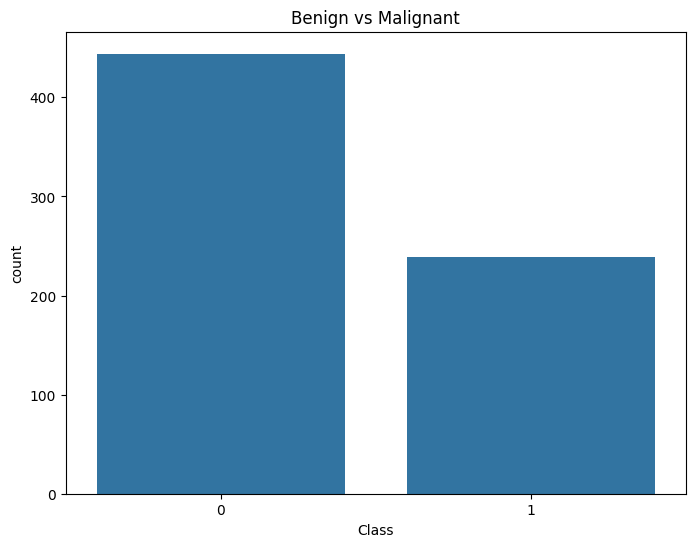

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class Distribution:
plt.figure(figsize=(8,6))
sns.countplot(x='Class', data=df)
plt.title('Benign vs Malignant')
plt.show()

#

# From this visualisation it is clearly showing that Benign cases are more frequent(~440) than Malignant(~240), showing a moderate class imbalance.

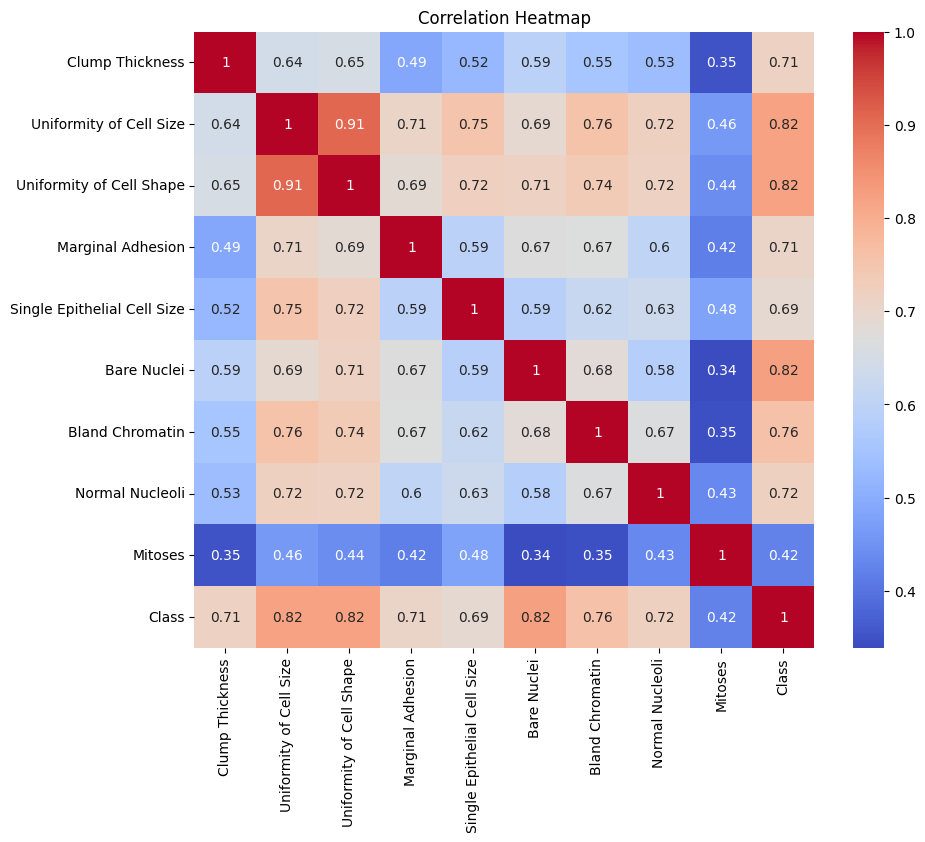

In [5]:
# Correlation Heatmap:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Some features are strongly correlated(Uniformity of Cell size and shape, Clump Thickness).

# If correlation is > 0.9, we would consider removing redundant features.

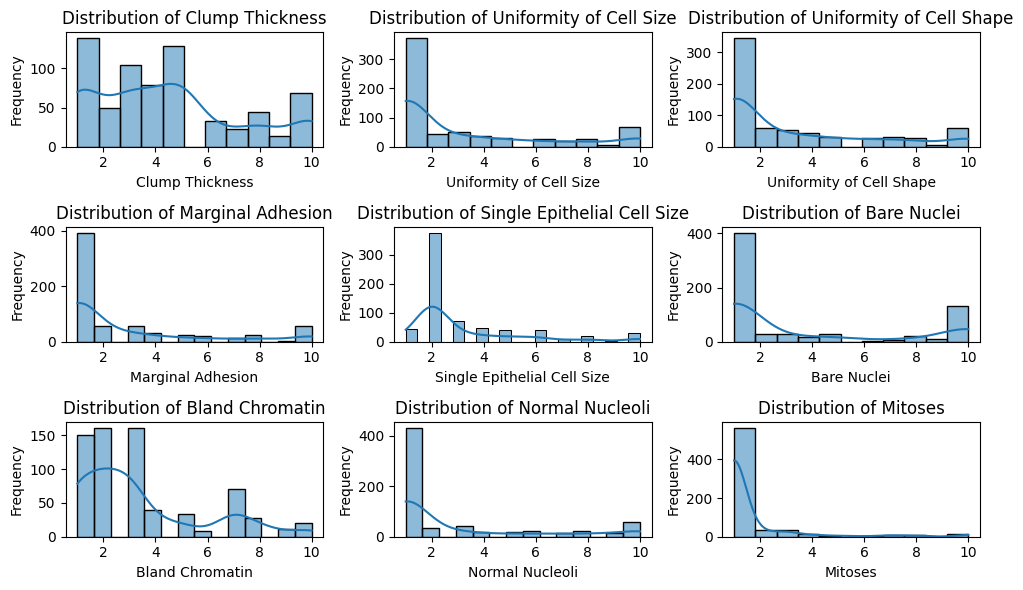

In [6]:
# Feature distributions:
plt.figure(figsize=(10,6))
for i, col in enumerate(df.columns[:-1],1):
  plt.subplot(3,3,i)
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Most features are distributed between 1-10, with malignant cases generally showing higher values for cell irregularities.

## Step-4: Train-Test-Split + Scaling

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=df.drop('Class',axis=1)
y=df['Class']

# Train-test-split(80/20):
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

# Scaling features:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


# In this code we basically split the dataset into 80% training and 20% testing. Features are standardized for models like kNN, Logistic Regression, and MLP.

## Evaluation Function

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,roc_auc_score
def evaluate_model(model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  y_pred_train=model.predict(X_train)
  y_pred_test=model.predict(X_test)
  y_prob_test=model.predict_proba(X_test)[:,1]

  f1_sc=f1_score(y_test,y_pred_test)
  acc_score=accuracy_score(y_test,y_pred_test)
  auc=roc_auc_score(y_test,y_prob_test)
  con_matrix=confusion_matrix(y_test,y_pred_test)
  print(f'F1 Score: {f1_sc}')
  print(f'AUC Score: {acc_score}')
  print(f'ROC AUC Score: {auc}')
  print(classification_report(y_test,y_pred_test))
  print(confusion_matrix(y_test,y_pred_test))
  return f1_sc,acc_score,auc,con_matrix

# We define a helper function to train models and compute F1-score, ROC-AUC, classification_report, confusion_matrix, and accuracy.

## Step-6 Train Models

In [9]:
# kNN:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn_f1,knn_acc,knn_auc,knn_con_matrix=evaluate_model(knn,X_train_scaled,X_test_scaled,y_train,y_test)

# Logistic Regression:
from sklearn.linear_model import LogisticRegression
lrr=LogisticRegression(max_iter=2000)
lrr_f1_sc,lrr_acc_score,lrr_auc,lrr_con_matrix=evaluate_model(lrr,X_train_scaled,X_test_scaled,y_train,y_test)

# Random Forest:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf_f1_sc,rf_acc_score,rf_auc,rf_con_matrix=evaluate_model(rf,X_train_scaled,X_test_scaled,y_train,y_test)

# MLP:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(16,8),max_iter=1000,random_state=42)
mlp_f1_sc,mlp_acc_score,mlp_auc,mlp_con_matrix=evaluate_model(mlp,X_train_scaled,X_test_scaled,y_train,y_test)

F1 Score: 0.9387755102040817
AUC Score: 0.9562043795620438
ROC AUC Score: 0.9776451310861424
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

[[85  4]
 [ 2 46]]
F1 Score: 0.9494949494949495
AUC Score: 0.9635036496350365
ROC AUC Score: 0.9918071161048689
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        89
           1       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137

[[85  4]
 [ 1 47]]
F1 Score: 0.9494949494949495
AUC Score: 0.9635036496350365
ROC AUC Score: 0.9859550561797753
              precision    re

1.Accuracy: ~ 96% across all models like (kNN, Logistic Regression, Random Forest, MLP).

2.F1-score: = 0.94–0.95 (balanced performance between precision & recall).

3.ROC AUC: very high (0.98–0.99), showing strong separability between benign and malignant cases.

4.Precision: ~ 0.92 for malignant, ~ 0.99 for benign.

5.Recall: ~0.96–0.98 - very few false negatives cases (important in cancer detection).

6.Confusion Matrix: Only ~ 1–2 malignant cases misclassified, and ~ 3–4 benign cases misclassified.

## Comapring Results:


In [15]:
# Compare results:
results_df=pd.DataFrame({
    'Model':['kNN','Logistic Regression','Random Forest','MLP'],
    'F1-Score':[knn_f1,lrr_f1_sc,rf_f1_sc,mlp_f1_sc],
    'ROC-AUC':[knn_auc,lrr_auc,rf_auc,mlp_auc],
    'Accuracy':[knn_acc,lrr_acc_score,rf_acc_score,mlp_acc_score]
})

results_df

,Model,F1-Score,ROC-AUC,Accuracy
0,kNN,0.938776,0.977645,0.956204
1,Logistic Regression,0.949495,0.991807,0.963504
2,Random Forest,0.949495,0.985955,0.963504
3,MLP,0.949495,0.992743,0.963504


# In the above code we compare F1-Score, ROC-AUC curve, and Accuracy across all models.

## Step-8 Feature Importance::

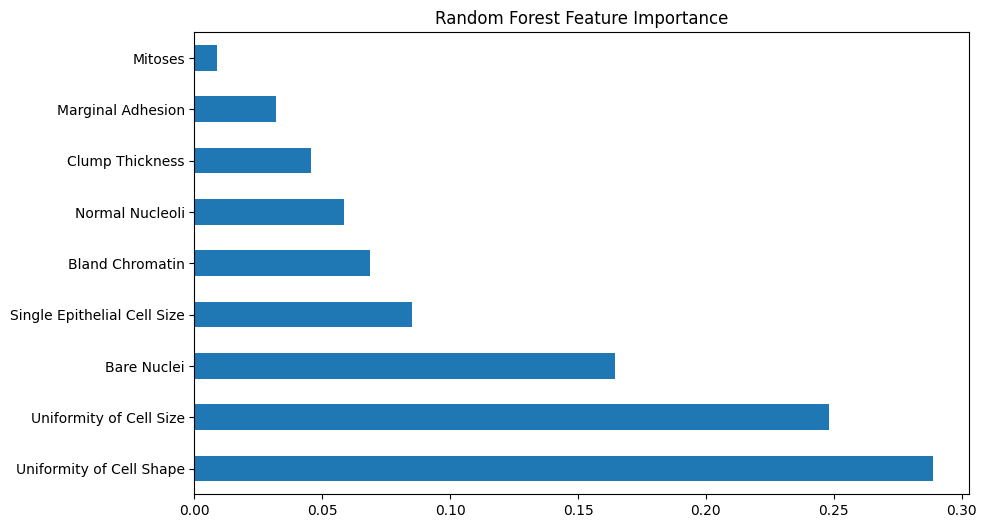

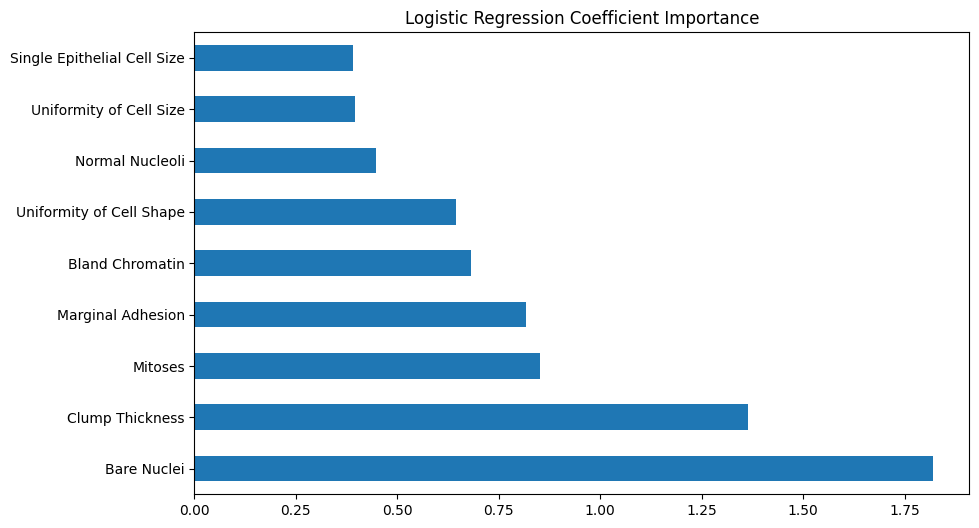

In [19]:
# Feature importance:
# Random Forest:
importances=pd.Series(rf.feature_importances_,index=x.columns)
importances.sort_values(ascending=False).plot(kind='barh',figsize=(10,6))
plt.title('Random Forest Feature Importance')
plt.show()

# Logistic Regression Coefficient:
coef_df=pd.Series(lrr.coef_[0], index=x.columns)
coef_df.sort_values(ascending=False).plot(kind='barh',figsize=(10,6))
plt.title('Logistic Regression Coefficient Importance')
plt.show()


1. Key features highlighted are Uniformity of Cell Size, Uniformity of Cell Shape, Clump Thickness, Bare Nuclei, and Normal Nucleoli.
2. These match well with established clinical findings, supporting the reliability of the model.


## Final result:
## Random Forest achieved both high F1 and ROC-AUC while also providing interpretable feature importances consistent with medical knowledge. Although MLP performed slightly better in ROC-AUC, it lacks interpretability. Therefore, Random Forest is considered the most suitable model for this dataset.